In [8]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

import yfinance as yf

import warnings
warnings.filterwarnings("ignore")

In [45]:
plt.style.use('dark_background')

plt.rcParams.update({
    # Figure
    "figure.figsize": (12, 4),
    "figure.dpi": 120,

    # Axes
    "axes.facecolor": "#111111",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.grid": True,

    # Grid
    "grid.color": "#444444",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,

    # Ticks
    "xtick.color": "white",
    "ytick.color": "white",

    # Legend
    "legend.facecolor": "#111111",
    "legend.edgecolor": "white",
    "legend.fontsize": 10,

    # Lines
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Font
    "font.size": 11,
    "font.family":      "DejaVu Sans",
})

In [28]:
df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

df.sort_values(by="Date", ascending=True, inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.reset_index(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [34]:
df.head()

,Date,Close,High,Low,Open,Volume,Moving-Avg
0,2023-01-03,123.096016,128.833995,122.210219,128.223785,112117500,NaN
1,2023-01-04,124.365669,126.629372,123.105873,124.887303,89113600,NaN
2,2023-01-05,123.046806,125.753403,122.790915,125.123505,80962700,NaN
3,2023-01-06,127.574203,128.233627,122.918861,124.021187,87754700,NaN
4,2023-01-09,128.095871,131.304429,127.839980,128.410828,70790800,NaN


In [38]:
df['Moving-Avg'] = df['Close'].rolling(window=30).mean()
df['Trend'] = df['Moving-Avg'].diff()
df[25:35]

,Date,Close,High,Low,Open,Volume,Moving-Avg,Trend
25,2023-02-08,149.522263,152.140284,148.784100,151.451335,64120100,NaN,NaN
26,2023-02-09,148.488815,151.894213,148.045921,151.352890,56007100,NaN,NaN
27,2023-02-10,148.853531,149.178820,147.089099,147.325677,57450700,NaN,NaN
28,2023-02-13,151.652985,152.057118,148.764818,148.794388,62199000,NaN,NaN
29,2023-02-14,151.012268,151.574136,148.705687,149.947689,61707600,138.914340,NaN
30,2023-02-15,153.111847,153.279417,150.696837,150.923548,65573800,139.914868,1.000528
31,2023-02-16,151.514984,154.097565,151.160124,151.317828,68167900,140.819845,0.904977
32,2023-02-17,150.371552,150.815122,148.695831,150.174411,59144100,141.730670,0.910825
33,2023-02-21,146.359665,149.139402,146.290672,148.055104,58867200,142.356852,0.626182
34,2023-02-22,146.783539,147.808681,145.058529,146.744102,51011300,142.979774,0.622922


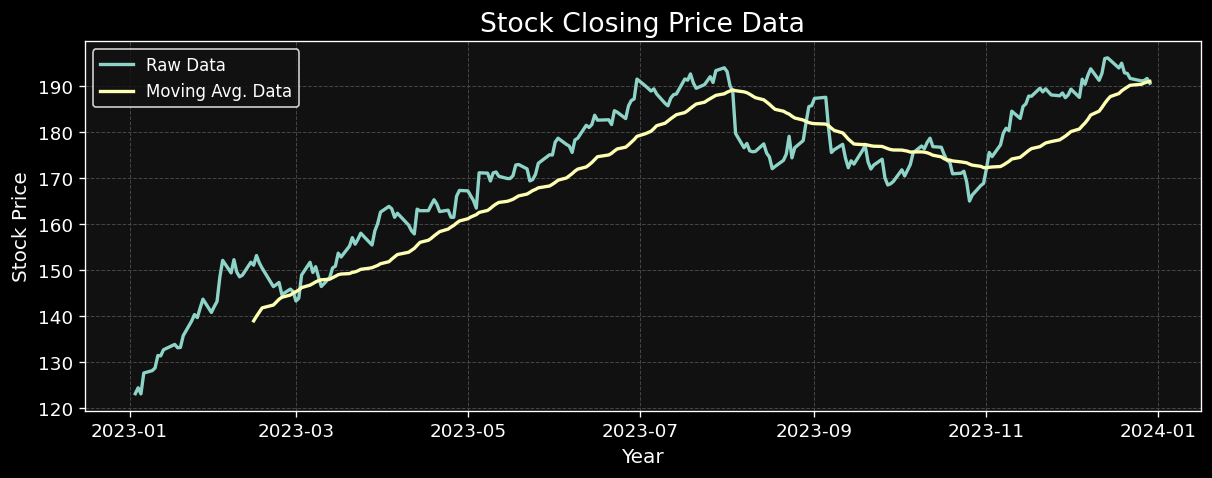

In [53]:
plt.plot(df['Date'], df['Close'], label ='Raw Data')
plt.plot(df['Date'], df['Moving-Avg'] , label = 'Moving Avg. Data')
plt.legend()
plt.xlabel('Year')
plt.ylabel('Stock Price')
plt.title('Stock Closing Price Data')
plt.show()

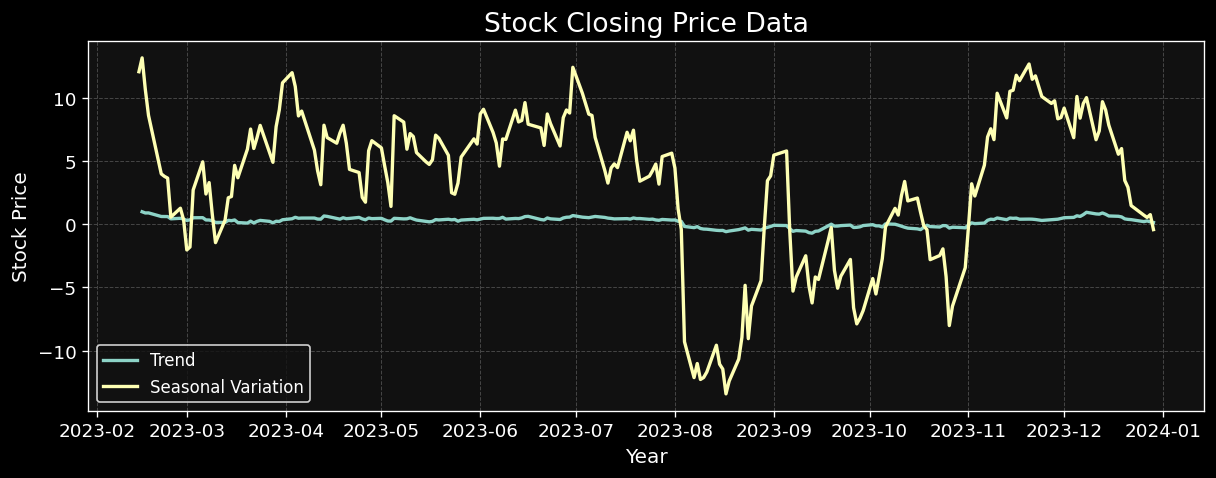

In [54]:
# Visualing Trend and Seosonal Variation
df['Seasonal_Variation'] = df['Close'] - df['Moving-Avg']

plt.plot(df['Date'], df['Trend'] , label = 'Trend')
plt.plot(df['Date'], df['Seasonal_Variation'] , label = 'Seasonal Variation')
plt.legend()
plt.xlabel('Year')
plt.ylabel('Stock Price')
plt.title('Stock Closing Price Data')
plt.show()

## **PRACTICAL-05**
Measurement of Seasonal indices Ratio-to-Trend method.

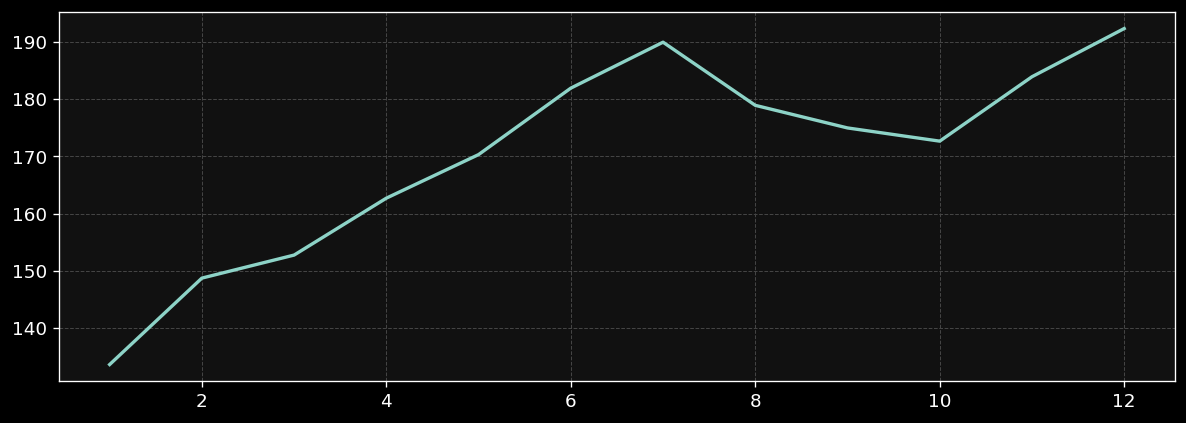

In [56]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

monthly_avg = df.groupby(['Month', 'Year'])['Close'].mean().unstack()

for i in range(2023, 2024):
    plt.plot(monthly_avg.index, monthly_avg[i], label=f'Month {i}')